In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

import objax
import bayesnewton
import xarray as xr
import seaborn as sns
import pickle
import time
from tqdm.notebook import tqdm

Load 8x16 grid of z500 values, for 14 days training and 3 days testing data sampled hourly

In [100]:
z500 = xr.open_mfdataset('data/5.625deg/geopotential_500/*.nc', combine='by_coords')
z500_train = z500.sel(time=slice('2017.12.1', '2017.12.14'), lat=slice(0, None, 2), lon=slice(0, None, 4))['z']
z500_test= z500.sel(time=slice('2017.12.15', '2017.12.17'), lat=slice(0, None, 2), lon=slice(0, None, 4))['z']

In [106]:
data_mean = z500_train.mean(axis=0).load()
data_std = z500_train.std(axis=0).load()
data_train = (z500_train - data_mean) / data_std # normalise

t_train = (data_train.time - data_train.time[0]).values # time in hours
t_train = t_train / np.timedelta64(1, 'h') # convert to hours

In [107]:
from model import ExactMarkovGP

In [108]:
lat = jnp.array(data_train.lat)
lon = jnp.array(data_train.lon)
t_train = jnp.array(t_train)
z_train = jnp.array(data_train.values)
z_train.shape

(336, 8, 16)

In [109]:
# Wrap arrays in format appropriate for the state space model
LAT, LON = jnp.meshgrid(lat, lon, indexing='ij')
R = jnp.stack([LAT.ravel(), LON.ravel()], axis=-1)
R = jnp.repeat(R[None, ...], z_train.shape[0], axis=0)
Y = z_train.reshape(-1, 8*16)
t_train.shape, R.shape, Y.shape

((336,), (336, 128, 2), (336, 128))

In [138]:
lengthscale_spatial = 0.1
lengthscale_temporal = 10.0
variance_spatial = 0.2
variance_temporal = 0.2

variance_noise = 1e-10 # Set very small to approximate no measurement noise

lik = bayesnewton.likelihoods.Gaussian(variance=variance_noise)
kern_time = bayesnewton.kernels.Matern52(variance=variance_temporal, lengthscale=lengthscale_temporal)
kern_space = bayesnewton.kernels.Matern52(variance=variance_spatial, lengthscale=lengthscale_spatial)
kernel = bayesnewton.kernels.SpatioTemporalKernel(temporal_kernel=kern_time, spatial_kernel=kern_space, z=R[0], sparse=False, opt_z=False)
gp = ExactMarkovGP(kernel, lik, X=t_train, R=R, Y=Y)

In [148]:
lr_adam = 0.5
epochs = 5

opt_hypers = objax.optimizer.Adam(gp.vars())
energy = objax.GradValues(gp.filter_energy, gp.vars())

def train_op():
    grads, loss_ = energy()  # compute energy and its gradients w.r.t. hypers
    opt_hypers(lr_adam, grads)
    return loss_[0]

train_op = objax.Jit(train_op, gp.vars())

t0 = time.time()
for i in range(1, epochs+1):
    loss = train_op()
    print('epoch %2d: loss: %1.4f' % (i, loss))
t1 = time.time()
print('optimisation time: %2.2f secs' % (t1-t0))

epoch  1: loss: 486628.0738
epoch  2: loss: 241941.1342
epoch  3: loss: 114210.6630
epoch  4: loss: 48126.2807
epoch  5: loss: 15613.6497
optimisation time: 58.77 secs


In [140]:
print(lengthscale_spatial, lengthscale_temporal, variance_spatial, variance_temporal)
gp.kernel.spatial_kernel.lengthscale, gp.kernel.temporal_kernel.lengthscale, gp.kernel.spatial_kernel.variance, gp.kernel.temporal_kernel.variance

0.1 10.0 0.2 0.2


(Array(0.1, dtype=float64, weak_type=True),
 Array(7.50050756, dtype=float64, weak_type=True),
 Array(0.2, dtype=float64, weak_type=True),
 Array(1.30758599, dtype=float64, weak_type=True))

In [141]:
# Normalize data_testsets
data_test = (z500_test - data_mean) / data_std

t_test = (data_test.time - data_train.time[0]).values
t_test = t_test / np.timedelta64(1, 'h')

In [149]:
train_mean, train_std = gp.predict(t_train)

In [150]:
test_mean, test_std = gp.predict(t_test)

In [151]:
train_mean = train_mean.reshape(-1, 8, 16)
train_std = train_std.reshape(-1, 8, 16)
test_mean = test_mean.reshape(-1, 8, 16)
test_std = test_std.reshape(-1, 8, 16)

In [152]:
data_train.shape, data_mean.shape, data_std.shape

((336, 8, 16), (8, 16), (8, 16))

In [146]:
def plot_std(x, y_mean, y_std, ax=None, **kwargs):
    if ax is None:
        fig, ax = plt.subplots()
    ax.fill_between(x, y_mean - y_std, y_mean + y_std, **kwargs)

Text(0.5, 1.0, 'geopotential at 500hPa (m)')

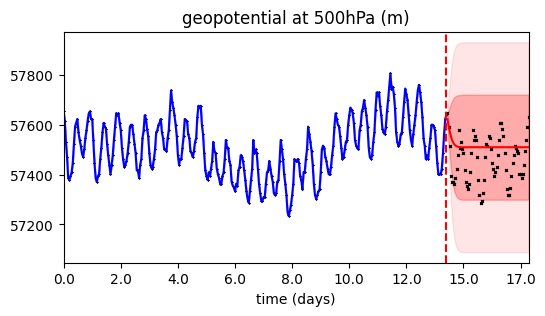

In [156]:
point = (slice(None),) + (0, 15)

data_mean, data_std = np.array(data_mean), np.array(data_std)
fig, ax = plt.subplots(figsize=(6, 3))
# Train/test data
ax.plot(t_train, (data_mean + data_train * data_std)[point], color='black', marker='x', linestyle='none', ms=1)
ax.plot(t_test, (data_mean + data_test * data_std)[point], color='black', marker='x', linestyle='none', ms=2)

# Train/test predictions and uncertainties
ax.plot(t_train, (data_mean + train_mean * data_std)[point], color='blue')
ax.plot(t_test, (data_mean + test_mean * data_std)[point], color='red')
plot_std(t_train, (data_mean + train_mean * data_std)[point], (train_std * data_std)[point], ax=ax, color='blue', alpha=0.25)
plot_std(t_test, (data_mean + test_mean * data_std)[point], (test_std * data_std)[point], ax=ax, color='red', alpha=0.25)
plot_std(t_train, (data_mean + train_mean * data_std)[point], 2 * (train_std * data_std)[point], ax=ax, color='blue', alpha=0.1)
plot_std(t_test, (data_mean + test_mean * data_std)[point], 2 * (test_std * data_std)[point], ax=ax, color='red', alpha=0.1)

ax.axvline(t_train[-1], color='red', linestyle='--')
ax.set_xticks(ax.get_xticks(), np.around(ax.get_xticks()/24));
ax.margins(x=0)
ax.set_xlabel('time (days)')
ax.set_title('geopotential at 500hPa (m)')

# With detrending